In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpl_patches

In [8]:
df=pd.read_table('166_SA_Mg_Blues_4boxplots.txt',sep='\t')
df.head()

,Accession_ID,Leaf_Mg_Blues,chr5_21394004
0,12766,3055.190882,0
1,12911,2904.392852,0
2,12912,2411.598233,1
3,13172,3007.566360,0
4,13173,2992.907810,0


In [16]:
df=df.loc[df['chr5_21394004'] != '.']
df.head()

,Accession_ID,Leaf_Mg_Blues,chr5_21394004
0,12766,3055.190882,0
1,12911,2904.392852,0
2,12912,2411.598233,1
3,13172,3007.566360,0
4,13173,2992.907810,0


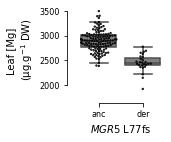

In [28]:
alt=df[df['chr5_21394004'] == '0']
ref=df[df['chr5_21394004'] == '1']



@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(4*cm,4*cm))
ax=sns.boxplot(x='chr5_21394004', 
            y='Leaf_Mg_Blues',
            color='grey',
            data=df,
            fliersize=0,
            linewidth=1.5)
ax=sns.swarmplot(x='chr5_21394004', 
            y='Leaf_Mg_Blues',
            color='0',
            data=df,
            s=0.8,
            linewidth=1.5)

# r,p = mannwhitneyu(alt['Leaf_Mg_Blues'],ref['Leaf_Mg_Blues'])
# handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
#                                  lw=0, alpha=0)] * 2
# labels=[]
# labels.append(r"$P$ = {:.2e}".format(p))
# plt.legend(handles, labels, loc='best', fontsize=8, 
#       fancybox=True, framealpha=0.7, 
#       handlelength=0, handletextpad=0)


ax.yaxis.set_major_locator(ticker.MultipleLocator(500))
sns.despine(trim=True,offset=10)
ax.set_xticklabels(['anc', 'der'])
plt.tick_params(labelsize=8)
plt.xlabel('$\itMGR5$ L77fs',fontsize=10)
plt.ylabel('Leaf [Mg] \n(µg.g$^{-1}$ DW)',fontsize=10)
plt.savefig("Fig4c.pdf", format="pdf",bbox_inches="tight")

In [22]:
r,p = mannwhitneyu(alt['Leaf_Mg_Blues'],ref['Leaf_Mg_Blues'])
print(r,p)

152.0 1.2243070861493855e-13
